# Haplotype analysis

This notebook demonstrates how to consider the combined effect of multiple variants in a haplotype, and compare the results to the individual effects of each variant. This can give an indication of any predicted cooperative effect.

## Imports

In [ ]:
# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output

! pip install alphagenome
clear_output()

In [ ]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.io import fasta
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

## Load the model and functions

Load the model:

In [ ]:
dna_model = dna_client.create(colab_utils.get_api_key())

Create a function to extract transcripts for plotting:

In [ ]:
# The GTF file contains information on the location of all transcripts
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Create an extractor to extract all MANE protein-coding transcripts
gtf_mane_protein = gene_annotation.filter_protein_coding(gtf)
gtf_mane_protein = gene_annotation.filter_to_mane_select_transcript(
    gtf_mane_protein
)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_mane_protein)

Create a function that creates a haplotype (a combination of variants):

In [ ]:
def create_haplotype(mutations: list[genome.Variant]) -> dict:
  """Fetches hg38 sequence, applies mutations, and returns a dictionary with:

  - 'combined_variant': A genome.Variant object for the entire range.
  - 'individual_variants': A dict of {pos: genome.Variant} for each mutation.
  """
  if not mutations:
    raise ValueError("Mutation list is empty.")

  # Check chromosome consistency
  chroms = {m.chromosome for m in mutations}
  if len(chroms) > 1:
    raise ValueError(f"Multiple chromosomes detected: {chroms}.")

  target_chr = list(chroms)[0]

  # Check 1MB Range constraint
  positions = [m.position for m in mutations]
  min_pos, max_pos = min(positions), max(positions)

  if (max_pos - min_pos) > 1_000_000:
    raise ValueError(
        f"Range too large: {max_pos - min_pos} bp. Max 1MB allowed."
    )

  # Fetch sequence from FastaExtractor
  # copybara:insert fasta_path = (
  # copybara:insert    "https://storage.googleapis.com/alphagenome/reference/"
  # copybara:insert    "gencode/hg38/GRCh38.p13.genome.fa"
  # copybara:insert )
  extractor = fasta.FastaExtractor(fasta_path)

  # FastaExtractor extract takes an Interval (start is 0-indexed, half-open)
  interval = genome.Interval(
      chromosome=target_chr, start=min_pos - 1, end=max_pos
  )
  raw_hg38_seq = extractor.extract(interval).upper()

  if not raw_hg38_seq:
    raise ValueError("No sequence data returned from FASTA.")

  # Prepare mutable lists for both output sequences
  ref_list = list(raw_hg38_seq)
  alt_list = list(raw_hg38_seq)
  individual_variants = {}

  print(f"--- Processing {target_chr}:{min_pos}-{max_pos} ---")

  # Apply Changes and Logging
  for mut in mutations:
    pos = mut.position
    alt_val = mut.alternate_bases.upper()
    current_ref = mut.reference_bases.upper()

    rel_index = pos - min_pos
    hg38_base = raw_hg38_seq[rel_index]

    print(f"\nPosition {pos}:")
    print(f"  - hg38 base: {hg38_base}")

    # Apply to sequence strings
    ref_list[rel_index] = current_ref
    alt_list[rel_index] = alt_val

    # Logging
    if current_ref != hg38_base:
      print(
          f"  - REF: CHANGING (hg38 '{hg38_base}' -> User Ref '{current_ref}')"
      )
    else:
      print(f"  - REF: No change (Using '{current_ref}')")

    if alt_val != hg38_base:
      print(f"  - ALT: CHANGING (hg38 '{hg38_base}' -> Alt '{alt_val}')")
    else:
      print(f"  - ALT: No change (Alt matches hg38)")

    individual_variants[pos] = mut

  # Build final output dictionary
  # Creating the 'combined' variant representing the whole stretch
  combined_ref = "".join(ref_list)
  combined_alt = "".join(alt_list)

  result = {
      "combined_variant": genome.Variant(
          chromosome=target_chr,
          position=min_pos,
          reference_bases=combined_ref,
          alternate_bases=combined_alt,
      ),
      "individual_variants": individual_variants,
  }

  print("\n--- Processing Complete ---")
  return result

## Analyse haplotype

Create the haplotype:

In [ ]:
# List alterations
mutation_data = [
    genome.Variant(
        chromosome='chr5',
        position=1295113,
        reference_bases='G',
        alternate_bases='A',
    ),
    genome.Variant(
        chromosome='chr5',
        position=1295135,
        reference_bases='G',
        alternate_bases='A',
    ),
]

# Get the single dictionary back that holds the ref and alt strings for both individual variants and combined (haplotype)
haplotype = create_haplotype(mutation_data)

print(f"Combined variant: \n {haplotype['combined_variant']}")
print(f"Individual Variants:\n {haplotype['individual_variants']}")

--- Processing chr5:1295113-1295135 ---

Position 1295113:
  - hg38 base: G
  - REF: No change (Using 'G')
  - ALT: CHANGING (hg38 'G' -> Alt 'A')

Position 1295135:
  - hg38 base: G
  - REF: No change (Using 'G')
  - ALT: CHANGING (hg38 'G' -> Alt 'A')

--- Processing Complete ---
Combined variant: 
 chr5:1295113:GGGGGCTGGGCCGGGGACCCGGG>AGGGGCTGGGCCGGGGACCCGGA
Individual Variants:
 {1295113: Variant(chromosome='chr5', position=1295113, reference_bases='G', alternate_bases='A', name=''), 1295135: Variant(chromosome='chr5', position=1295135, reference_bases='G', alternate_bases='A', name='')}


Score each variant individually and as a combined variant (haplotype):

In [ ]:
# Create a 1MB interval centered on the combined_variant
interval = haplotype['combined_variant'].reference_interval.resize(
    dna_client.SEQUENCE_LENGTH_1MB
)

# Define the shared parameters to keep the code clean
prediction_params = {
    'interval': interval,
    'requested_outputs': [
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.ATAC,
    ],
    'ontology_terms': ['UBERON:0002107'],
}

# Predict for the combined variant (the haplotype)
all_predictions = {}
all_predictions['combined'] = dna_model.predict_variant(
    variant=haplotype['combined_variant'], **prediction_params
)

# Predict for each individual variant
for pos, var_obj in haplotype['individual_variants'].items():
  all_predictions[pos] = dna_model.predict_variant(
      variant=var_obj, **prediction_params
  )

## Visualise haplotype

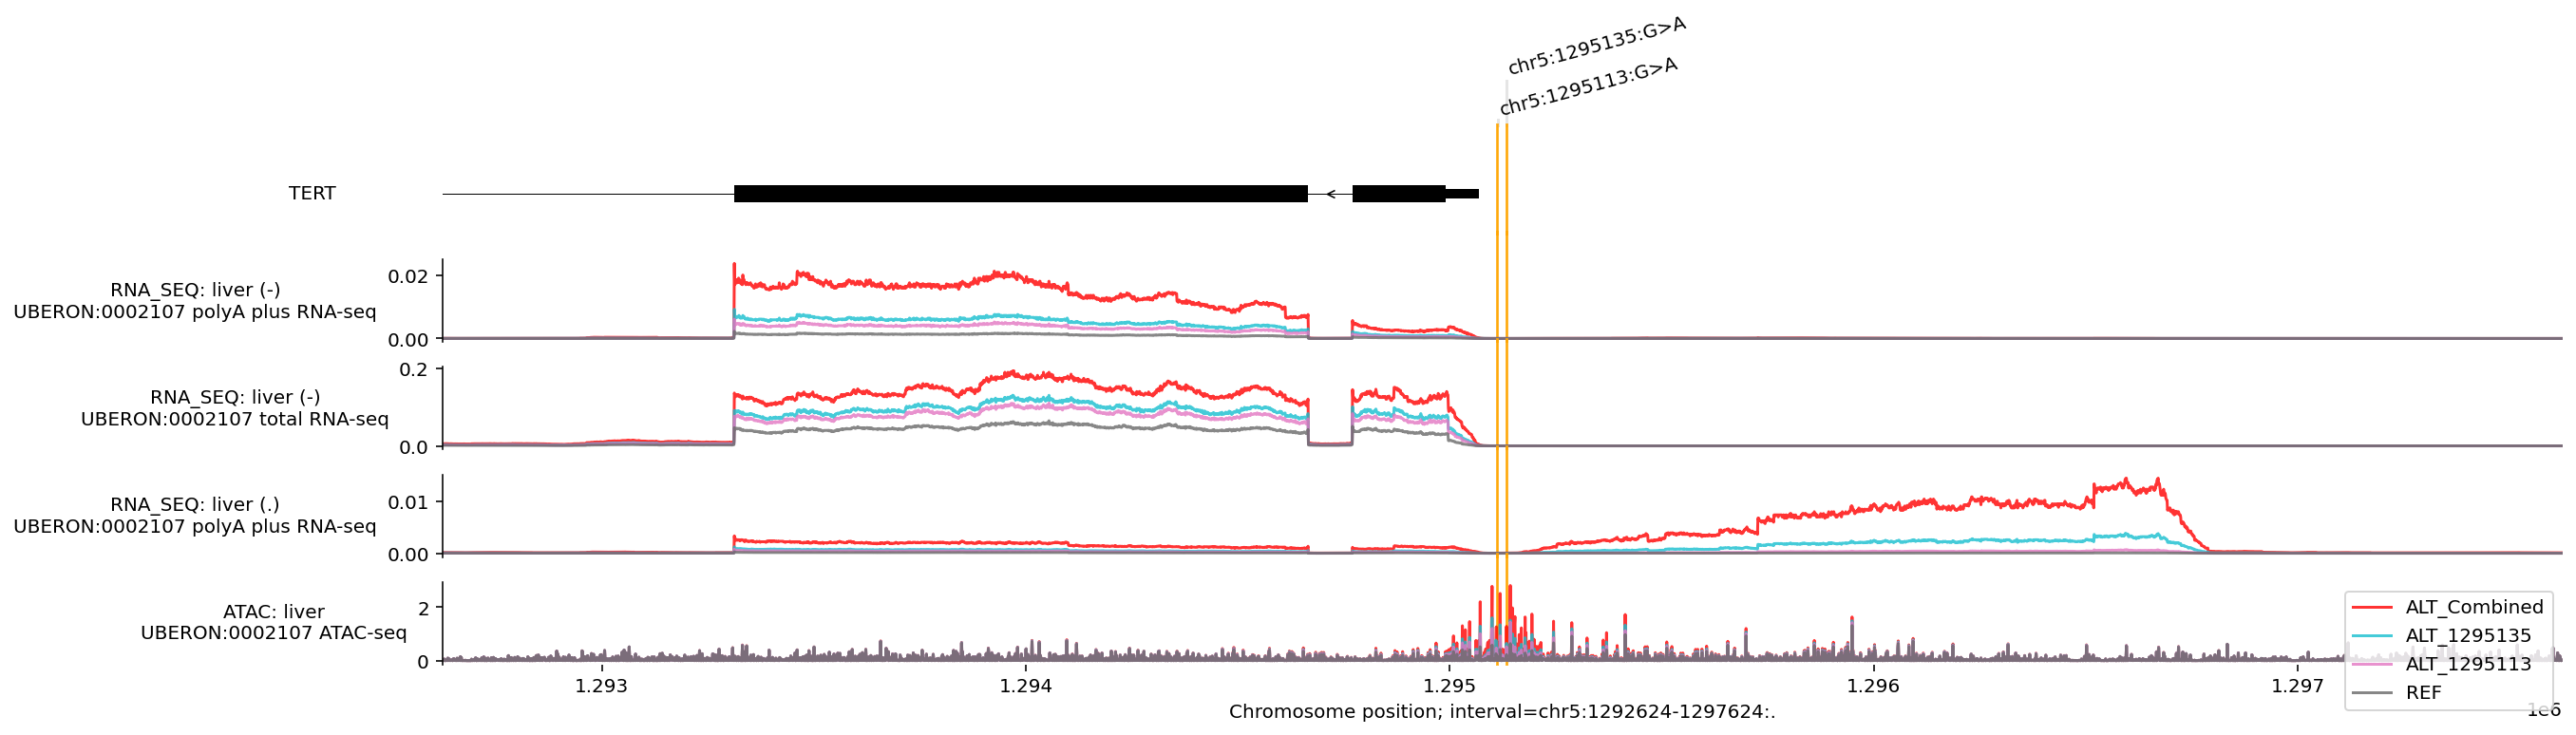

In [ ]:
# Setup colours (matching for both sets of tracks)
REF_COLOR = 'dimgrey'
COMBINED_COLOR = 'red'
palette = ['#e377c2', '#17becf', '#1f77b4', '#2ca02c', '#9467bd', '#8c564b']

# Initialize containers for both modalities
tdata_rna = {}
tdata_atac = {}
colors = {}
annotations = []

# --- Reference Tracks ---
tdata_rna['REF'] = all_predictions[
    'combined'
].reference.rna_seq.filter_to_nonpositive_strand()
tdata_atac['REF'] = all_predictions['combined'].reference.atac
colors['REF'] = REF_COLOR

# --- Combined Variant Tracks ---
tdata_rna['ALT_Combined'] = all_predictions[
    'combined'
].alternate.rna_seq.filter_to_nonpositive_strand()
tdata_atac['ALT_Combined'] = all_predictions['combined'].alternate.atac
colors['ALT_Combined'] = COMBINED_COLOR

# --- Individual Variant Tracks & Annotations ---
for i, (pos, var_obj) in enumerate(haplotype['individual_variants'].items()):
  variant_color = palette[i % len(palette)]
  track_key = f'ALT_{pos}'

  # RNA tracks (filtered)
  tdata_rna[track_key] = all_predictions[
      pos
  ].alternate.rna_seq.filter_to_nonpositive_strand()
  # ATAC tracks (unfiltered)
  tdata_atac[track_key] = all_predictions[pos].alternate.atac

  colors[track_key] = variant_color

  # Annotate individual variants
  annotations.append(plot_components.VariantAnnotation([var_obj], alpha=0.8))

# Build plot
transcripts = transcript_extractor.extract(interval)

plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.OverlaidTracks(
            tdata=tdata_rna,
            colors=colors,
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
            legend_loc=None,
        ),
        plot_components.OverlaidTracks(
            tdata=tdata_atac,
            colors=colors,
            ylabel_template='ATAC: {biosample_name}\n{name}',
        ),
    ],
    interval=interval.resize(5000),
    annotations=annotations,
)
plt.show()

These two mutations (rs1242535815 and rs1242535816) individually create a de novo binding site for a specific group of proteins called ETS transcription factors (specifically GABPA). These two mutations are almost always mutually exclusive in cancer as one mutation is usually enough to grant immortality. AlphaGenome has predicted that having both sites mutated would have a greater effect - this may be due to cooperative binding of GABPA at both sites, or a larger window of increased accessibility.